Name: NAGARAMPALLI SARVAN KUMAR

Roll Number: CH.SC.U4CSE24130

In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Dataset: Old Faithful geyser, Yellowstone National Park, Wyoming, USA (R `datasets::faithful`, 272 observations). `eruptions` is the eruption duration in minutes and `waiting` is the waiting time to the next eruption in minutes.

In [2]:
data = pd.read_csv('06-kmeans-dataset-task-1.csv')

In [3]:
data.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [4]:
data.shape

(272, 2)

In [5]:
data.describe()

,eruptions,waiting
count,272.000000,272.000000
mean,3.487783,70.897059
std,1.141371,13.594974
min,1.600000,43.000000
25%,2.162750,58.000000
50%,4.000000,76.000000
75%,4.454250,82.000000
max,5.100000,96.000000


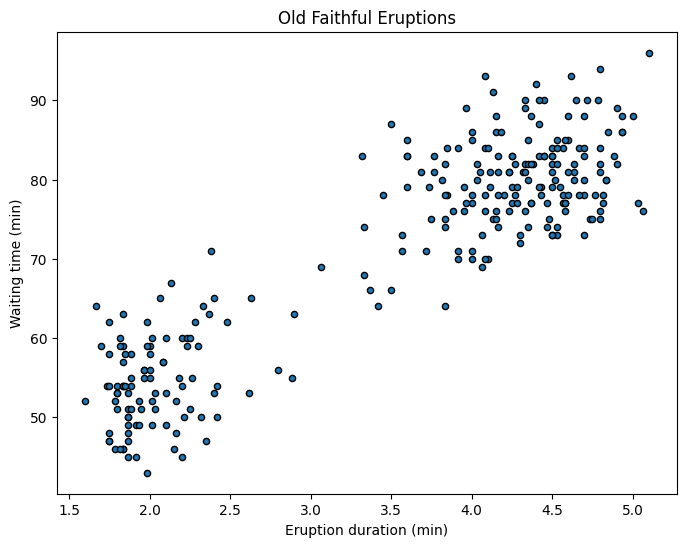

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(data['eruptions'], data['waiting'], s=20, edgecolors='k')
plt.xlabel('Eruption duration (min)'); plt.ylabel('Waiting time (min)')
plt.title('Old Faithful Eruptions')
plt.show()

The two features are on different scales (eruptions is 1.6–5.1 and waiting is 43–96), so they are standardised first. Without this, waiting time would dominate the distance calculation.

In [7]:
X = data[['eruptions', 'waiting']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Elbow method: inertia (within-cluster sum of squares) for k = 1 to 8.

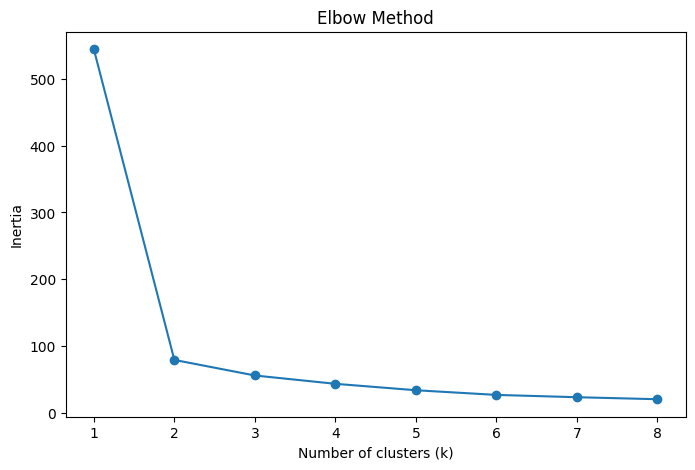

In [8]:
inertias = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled).inertia_ for k in range(1, 9)]

plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), inertias, 'o-')
plt.xlabel('Number of clusters (k)'); plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [9]:
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_scaled)
    print(f"k = {k}: silhouette score = {silhouette_score(X_scaled, labels):.4f}")

k = 2: silhouette score = 0.7452
k = 3: silhouette score = 0.4851
k = 4: silhouette score = 0.3822
k = 5: silhouette score = 0.3628


k = 6: silhouette score = 0.3920


The elbow is at k = 2, and k = 2 also has the highest silhouette score, so the eruptions are segmented into 2 clusters.

In [10]:
model = KMeans(n_clusters=2, n_init=10, random_state=42)
data['Cluster'] = model.fit_predict(X_scaled)

In [11]:
centres = pd.DataFrame(scaler.inverse_transform(model.cluster_centers_), columns=['eruptions', 'waiting'])
centres.index.name = 'Cluster'
print("Cluster centres (original units, minutes)")
print("---------------------------")
print(centres.round(2))

Cluster centres (original units, minutes)
---------------------------
         eruptions  waiting
Cluster                    
0             4.30    80.08
1             2.05    54.59


In [12]:
print("Cluster summary")
print("---------------------------")
print(data.groupby('Cluster')[['eruptions', 'waiting']].agg(['count', 'mean', 'min', 'max']).round(2))

Cluster summary
---------------------------
        eruptions                   waiting               
            count  mean   min   max   count   mean min max
Cluster                                                   
0             174  4.30  3.07  5.10     174  80.08  64  96
1              98  2.05  1.60  3.42      98  54.59  43  71


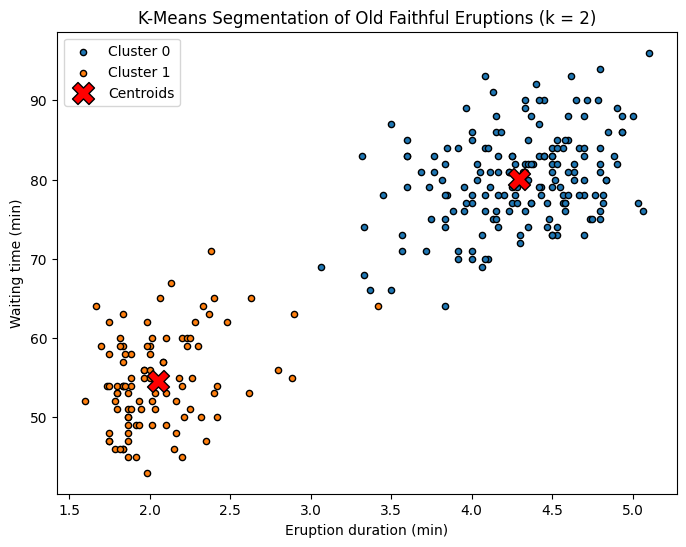

In [13]:
plt.figure(figsize=(8, 6))
for cluster, colour in [(0, 'tab:blue'), (1, 'tab:orange')]:
    pts = data[data['Cluster'] == cluster]
    plt.scatter(pts['eruptions'], pts['waiting'], c=colour, s=20, edgecolors='k', label=f'Cluster {cluster}')
plt.scatter(centres['eruptions'], centres['waiting'], c='red', marker='X', s=250, edgecolors='k', label='Centroids')
plt.xlabel('Eruption duration (min)'); plt.ylabel('Waiting time (min)')
plt.title('K-Means Segmentation of Old Faithful Eruptions (k = 2)')
plt.legend()
plt.show()

In [14]:
short = centres['eruptions'].idxmin()
long_ = centres['eruptions'].idxmax()
print(f"Cluster {short}: short eruptions (~{centres.loc[short, 'eruptions']:.2f} min) followed by short waits (~{centres.loc[short, 'waiting']:.0f} min)")
print(f"Cluster {long_}: long eruptions (~{centres.loc[long_, 'eruptions']:.2f} min) followed by long waits (~{centres.loc[long_, 'waiting']:.0f} min)")

Cluster 1: short eruptions (~2.05 min) followed by short waits (~55 min)
Cluster 0: long eruptions (~4.30 min) followed by long waits (~80 min)
